# Explatory Data Analysis

This notebook implements the EDA stage for the BRFSS heart-disease dataset.

#### Goals
- inspect dataset dimensions and target balance
- remove identifiers and survey-administration variables from the first baseline
- detect constant columns
- detect extremely sparse columns (>95% missing)
- record exactly why each column was removed

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Load the data

In [2]:
X_TRAIN_PATH = Path("./dataset/x_train.csv")
Y_TRAIN_PATH = Path("./dataset/y_train.csv")

def load_csv_with_header(path):
    with open(path, "r", newline="") as f:
        reader = csv.reader(f)
        header = np.array(next(reader))
        rows = []
        for row in reader:
            rows.append([
                np.nan if value == "" else float(value)
                for value in row
            ])
    return header, np.asarray(rows, dtype=float)

feature_names, x_train = load_csv_with_header(X_TRAIN_PATH)
target_names, y_data = load_csv_with_header(Y_TRAIN_PATH)

if y_data.shape[1] == 1:
    y_train = y_data[:, 0]
else:
    idx = [i for i, name in enumerate(target_names) if name != "Id"]
    if len(idx) != 1:
        raise ValueError("Could not uniquely identify target column.")
    y_train = y_data[:, idx[0]]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)


x_train shape: (328135, 322)
y_train shape: (328135,)


### Observations 

The dataset contains a large number of features (322 in total). In the following steps, we identify features that are irrelevant, redundant, or insufficiently informative for our prediction task. These features are then removed to obtain a cleaner and more interpretable dataset.

In [3]:
def find_constant_features(x, names):
    constant = []
    for j in range(x.shape[1]):
        valid = x[:, j][~np.isnan(x[:, j])]
        if len(valid) == 0 or len(np.unique(valid)) <= 1:
            constant.append(names[j])
    return constant

constant_features = find_constant_features(x_train, feature_names)

print("Constant / empty columns:", len(constant_features))
for feature in constant_features:
    print(" -", feature)


Constant / empty columns: 6
 - CTELENUM
 - COLGHOUS
 - STATERES
 - CTELNUM1
 - CELLFON2
 - CCLGHOUS


## 1.2. Dataset overview

Let's inspect the number of observations, columns and class imbalance.

In [4]:
print(f"Observations: {x_train.shape[0]}")
print(f"Columns: {x_train.shape[1]}")

classes, counts = np.unique(y_train, return_counts=True)

print("\nTarget distribution:")
for c, count in zip(classes, counts):
    print(f"class {int(c)}: {count} ({100*count/len(y_train):.2f}%)")


Observations: 328135
Columns: 322

Target distribution:
class -1: 299160 (91.17%)
class 1: 28975 (8.83%)


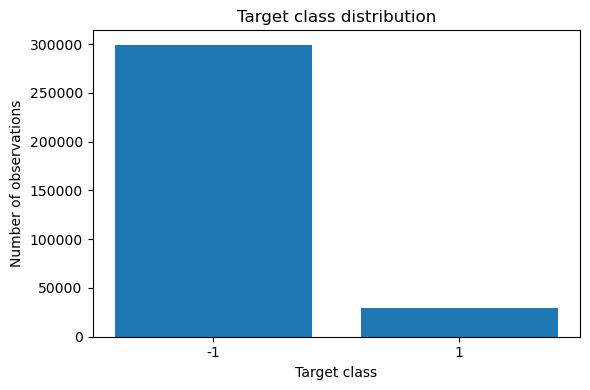

In [5]:
plt.figure(figsize=(6, 4))
labels = [str(int(c)) if float(c).is_integer() else str(c) for c in classes]
plt.bar(labels, counts)
plt.xlabel("Target class")
plt.ylabel("Number of observations")
plt.title("Target class distribution")
plt.tight_layout()
plt.show()


### Observation

The target is imbalanced, so later model evaluation should not rely on accuracy alone. A majority-class classifier can obtain high accuracy without learning a useful decision rule.


## 1.3. Define columns excluded from the first baseline

The BRFSS data mixes health/lifestyle information with identifiers and survey-design metadata. All of these informations were found by reading the [CDC codebook](https://www.cdc.gov/brfss/annual_data/2015/pdf/CODEBOOK15_LLCP.pdf).

For the first baseline, we exclude the variables below because they do not directly describe the respondent's health or lifestyle.


In [6]:
identifier_features = [
    "Id",
    "SEQNO",
    "_PSU",
]

survey_features = [
    "_STATE",
    "FMONTH",
    "IDATE",
    "IMONTH",
    "IDAY",
    "IYEAR",
    "DISPCODE",
    "QSTVER",
    "QSTLANG",
    "_STSTR",
    "_STRWT",
    "_RAWRAKE",
    "_WT2RAKE",
    "_CLLCPWT",
    "_DUALUSE",
    "_DUALCOR",
    "_LLCPWT",
]


## 1.4. Detect constant columns

Columns with no observed variation cannot help distinguish between observations.


In [7]:
def find_constant_features(x, names):
    constant = []
    for j in range(x.shape[1]):
        valid = x[:, j][~np.isnan(x[:, j])]
        if len(valid) == 0 or len(np.unique(valid)) <= 1:
            constant.append(names[j])
    return constant

constant_features = find_constant_features(x_train, feature_names)

print("Constant / empty columns:", len(constant_features))
for feature in constant_features:
    print(" -", feature)


Constant / empty columns: 6
 - CTELENUM
 - COLGHOUS
 - STATERES
 - CTELNUM1
 - CELLFON2
 - CCLGHOUS


The six columns above contain no useful variation in the training data: after ignoring missing values, each of them has at most one unique observed value. Since a constant feature cannot help distinguish between individuals or improve the classifier, these columns can safely be removed from the dataset.


## 1.5. Missing-value analysis

BRFSS contains many conditional questions, so missing values are due to the structure of the survey. For the first baseline, we remove features with more than 95% missing observations.


In [8]:
def compute_missing_rates(x, names):
    return {
        name: np.mean(np.isnan(x[:, j]))
        for j, name in enumerate(names)
    }

missing_rates = compute_missing_rates(x_train, feature_names)

for threshold in [0.10, 0.20, 0.50, 0.80, 0.90, 0.95, 0.99]:
    n = sum(rate >= threshold for rate in missing_rates.values())
    print(f">= {100*threshold:5.1f}% missing: {n} columns")


>=  10.0% missing: 182 columns
>=  20.0% missing: 178 columns
>=  50.0% missing: 147 columns
>=  80.0% missing: 116 columns
>=  90.0% missing: 99 columns
>=  95.0% missing: 68 columns
>=  99.0% missing: 30 columns


In [9]:
MISSING_THRESHOLD = 0.95

sparse_features = [
    name for name in feature_names
    if missing_rates[name] > MISSING_THRESHOLD
]

print(f"Columns with >{100*MISSING_THRESHOLD:.0f}% missing: {len(sparse_features)}")

for feature in sorted(sparse_features, key=lambda f: missing_rates[f], reverse=True):
    print(f"{feature:<15} {100*missing_rates[feature]:6.2f}%")


Columns with >95% missing: 68
COLGHOUS         99.99%
LADULT           99.99%
PCDMDECN         99.95%
ASERVIST         99.93%
ASDRVIST         99.93%
ASNOSLEP         99.90%
ASTHMED3         99.85%
ASINHALR         99.85%
ASYMPTOM         99.85%
ASRCHKUP         99.85%
ASACTLIM         99.85%
ASATTACK         99.85%
STREHAB1         99.84%
PCPSADE1         99.82%
HAREHAB1         99.76%
ASTHMAGE         99.76%
VINOCRE2         99.76%
CCLGHOUS         99.76%
HPVADSHT         99.67%
VIEYEXM2         99.43%
VIMACDG2         99.28%
VICTRCT4         99.28%
VIGLUMA2         99.28%
VIINSUR2         99.28%
VIREDIF3         99.28%
VIPRFVS2         99.28%
VIDFCLT2         99.28%
PCPSARS1         99.20%
PSATIME          99.20%
CDHELP           99.06%
LENGEXAM         98.87%
RLIVPAIN         98.72%
RDUCSTRK         98.72%
RDUCHART         98.72%
PROFEXAM         98.71%
CASTHNO2         98.53%
PCPSARE1         98.52%
PSATEST1         98.52%
PCPSADI1         98.52%
PCPSAAD2         98.51%
HPLSTTST  

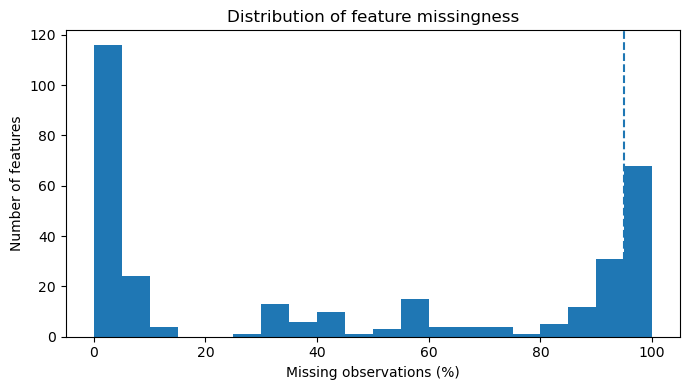

In [10]:
rates = np.array(list(missing_rates.values()))

plt.figure(figsize=(7, 4))
plt.hist(100 * rates, bins=20)
plt.axvline(100 * MISSING_THRESHOLD, linestyle="--")
plt.xlabel("Missing observations (%)")
plt.ylabel("Number of features")
plt.title("Distribution of feature missingness")
plt.tight_layout()
plt.show()


## 1.6. Remove selected columns

The removal list is determined from the training set only. The same list should later be applied unchanged to the test set.


In [11]:
features_to_remove = set(identifier_features + survey_features + constant_features + sparse_features)

keep_mask = np.array([
    name not in features_to_remove
    for name in feature_names
])

x_train_clean = x_train[:, keep_mask]
feature_names_clean = feature_names[keep_mask]

print("Shape before cleaning:", x_train.shape)
print("Shape after cleaning: ", x_train_clean.shape)
print("Removed columns:", np.sum(~keep_mask))
print("Retained columns:", np.sum(keep_mask))


Shape before cleaning: (328135, 322)
Shape after cleaning:  (328135, 230)
Removed columns: 92
Retained columns: 230


In [12]:
print("===================================")
print("FEATURE REMOVAL SUMMARY")
print("===================================")
print("Original columns:         ", len(feature_names))
print("Identifiers:              ", sum(f in feature_names for f in identifier_features))
print("Survey/admin variables:   ", sum(f in feature_names for f in survey_features))
print("Constant/empty variables: ", len(constant_features))
print(f">{100*MISSING_THRESHOLD:.0f}% missing variables:    ", len(sparse_features))
print("Unique columns removed:   ", len(features_to_remove))
print("Remaining columns:        ", len(feature_names_clean))


FEATURE REMOVAL SUMMARY
Original columns:          322
Identifiers:               3
Survey/admin variables:    17
Constant/empty variables:  6
>95% missing variables:     68
Unique columns removed:    92
Remaining columns:         230


## 1.7. Save retained and removed feature lists

To be reused in final preprocessing pipeline.

In [ ]:
with open("./dataset/retained_features.txt", "w") as f:
    for name in feature_names_clean:
        f.write(name + "\n")

with open("./dataset/removed_features.txt", "w") as f:
    for name in sorted(features_to_remove):
        f.write(name + "\n")

print("Saved retained_features.txt and removed_features.txt")


Saved retained_features.txt and removed_features.txt


# 2. Feature Types and BRFSS Encoding

The BRFSS dataset contains a mixture of binary, categorical, ordinal, and continuous variables. These feature types should not be processed in the same way. Before visualizing distributions or training models, we therefore classify the retained features according to their data type and inspect special response codes such as *Don't know*, *Refused*, or *Not applicable*. These codes must be handled carefully because they do not represent ordinary numerical values.


In [15]:
def summarize_feature_types(x, names):
    summary = []

    for j, name in enumerate(names):
        column = x[:, j]

        valid = column[~np.isnan(column)]
        unique_values = np.unique(valid)

        summary.append({
            "name": name,
            "n_unique": len(unique_values),
            "min": np.min(valid) if len(valid) > 0 else np.nan,
            "max": np.max(valid) if len(valid) > 0 else np.nan,
            "unique_values": unique_values[:20]
        })

    return summary


feature_summary = summarize_feature_types(
    x_train_clean,
    feature_names_clean
)

for feature in feature_summary:
    print(
        feature["name"],
        "| unique:", feature["n_unique"],
        "| range:", feature["min"], "-", feature["max"],
        "| values:", feature["unique_values"]
    )

PVTRESD1 | unique: 2 | range: 1.0 - 2.0 | values: [1. 2.]
CELLFON3 | unique: 2 | range: 1.0 - 2.0 | values: [1. 2.]
NUMADULT | unique: 16 | range: 1.0 - 20.0 | values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 14. 15. 18. 20.]
NUMMEN | unique: 12 | range: 0.0 - 18.0 | values: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 18.]
NUMWOMEN | unique: 11 | range: 0.0 - 10.0 | values: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
CADULT | unique: 2 | range: 1.0 - 2.0 | values: [1. 2.]
PVTRESD2 | unique: 2 | range: 1.0 - 2.0 | values: [1. 2.]
CSTATE | unique: 2 | range: 1.0 - 2.0 | values: [1. 2.]
LANDLINE | unique: 4 | range: 1.0 - 9.0 | values: [1. 2. 7. 9.]
HHADULT | unique: 25 | range: 1.0 - 99.0 | values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 18. 20. 21.
 22. 23.]
GENHLTH | unique: 7 | range: 1.0 - 9.0 | values: [1. 2. 3. 4. 5. 7. 9.]
PHYSHLTH | unique: 33 | range: 1.0 - 99.0 | values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19